# **I2_MARINO_REG TEST**

Esta libreta contiene el archivo I2_reg.py pero distribuido en celdas.


In [3]:

#! Did in 11 July for complete marino process 

import marimo

__generated_with = "0.23.9"
app = marimo.App()

# ============================================================
# IMPORTACIONES Y CONFIGURACIÓN GENERAL
# ============================================================

@app.cell
def _():
    import os
    import math
    from datetime import datetime

    import marimo as mo
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    import torch.nn as nn

    from torch.utils.tensorboard import SummaryWriter
    from torchvision import datasets, transforms

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"Dispositivo seleccionado: {device}")

    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("El entrenamiento se realizará con CPU.")

    return (
        SummaryWriter,
        datasets,
        datetime,
        device,
        mo,
        nn,
        os,
        plt,
        torch,
        transforms,
    )

In [4]:

#Only use this cell if you want to install marimo in your environment

# ! import sys

# ! !{sys.executable} -m pip install marimo

In [5]:
# ============================================================
# SEMILLAS PARA REPRODUCIBILIDAD
# ============================================================

@app.cell
def _(torch):
    seed = 42

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    return (seed,)


In [6]:
# ============================================================
# DATASET DE ENTRENAMIENTO
# ============================================================

@app.cell
def _(datasets, transforms):
    full_train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transforms.ToTensor(),
    )

    print(
        "Número total de imágenes de entrenamiento:",
        len(full_train_dataset),
    )

    return (full_train_dataset,)

In [7]:

# ============================================================
# DATASET DE PRUEBA
# ============================================================

@app.cell
def _(datasets, transforms):
    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        download=True,
        transform=transforms.ToTensor(),
    )

    print(
        "Número total de imágenes de prueba:",
        len(test_dataset),
    )

    return (test_dataset,)

Dispositivo seleccionado: cpu
El entrenamiento se realizará con CPU.
Número total de imágenes de entrenamiento: 60000
Número total de imágenes de prueba: 10000
Cantidad de índices seleccionados: 3000
Tamaño del dataset reducido: 3000


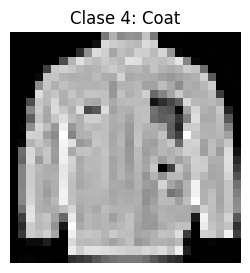

Muestras de entrenamiento: 2400
Muestras de validación: 600
Lotes de entrenamiento: 38
Lotes de validación: 10
Lotes de prueba: 157
Lambda L2: 0.001
Directorio de TensorBoard: runs\fashion_mnist_l2_0.001_20260730-151217
Número de parámetros entrenables: 535818
Epoch [001/300] | Train Loss: 2.2899 | Objective: 2.4195 | Train Acc: 0.1475 | Val Loss: 2.2678 | Val Acc: 0.2167 | Gap: -0.0221
Epoch [002/300] | Train Loss: 2.2445 | Objective: 2.3740 | Train Acc: 0.2621 | Val Loss: 2.2241 | Val Acc: 0.3000 | Gap: -0.0204
Epoch [003/300] | Train Loss: 2.1925 | Objective: 2.3220 | Train Acc: 0.3392 | Val Loss: 2.1695 | Val Acc: 0.4217 | Gap: -0.0231
Epoch [004/300] | Train Loss: 2.1266 | Objective: 2.2562 | Train Acc: 0.4462 | Val Loss: 2.0986 | Val Acc: 0.4383 | Gap: -0.0280
Epoch [005/300] | Train Loss: 2.0425 | Objective: 2.1722 | Train Acc: 0.4679 | Val Loss: 2.0057 | Val Acc: 0.4733 | Gap: -0.0368
Epoch [006/300] | Train Loss: 1.9381 | Objective: 2.0679 | Train Acc: 0.4817 | Val Loss: 1.892

In [8]:

# ============================================================
# MAPA DE ETIQUETAS
# ============================================================

@app.cell
def _():
    id_label_map = {
        0: "T-shirt/top",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle boot",
    }

    return (id_label_map,)


# ============================================================
# FUNCIÓN PARA MOSTRAR UNA IMAGEN
# ============================================================

@app.cell
def _(id_label_map, plt):
    def plot_sample(data, label):
        plt.figure(figsize=(3, 3))
        plt.imshow(data.squeeze(), cmap="gray")
        plt.title(
            f"Clase {label}: {id_label_map[int(label)]}"
        )
        plt.axis("off")
        plt.show()

    return (plot_sample,)


# ============================================================
# SELECCIÓN ALEATORIA DE 3000 MUESTRAS
# ============================================================

@app.cell
def _(full_train_dataset, seed, torch):
    number_of_samples = 3000

    sample_generator = torch.Generator()
    sample_generator.manual_seed(seed)

    indices = torch.randperm(
        len(full_train_dataset),
        generator=sample_generator,
    )[:number_of_samples]

    print("Cantidad de índices seleccionados:", len(indices))

    return (indices,)


# ============================================================
# CREACIÓN DEL DATASET REDUCIDO
# ============================================================

@app.cell
def _(full_train_dataset, indices, torch):
    small_dataset = torch.utils.data.Subset(
        full_train_dataset,
        indices,
    )

    print("Tamaño del dataset reducido:", len(small_dataset))

    return (small_dataset,)


# ============================================================
# VISUALIZACIÓN DE UNA MUESTRA
# ============================================================

@app.cell
def _(plot_sample, small_dataset):
    _sample_index = 1000

    _image, _label = small_dataset[_sample_index]

    plot_sample(_image, _label)

    return


# ============================================================
# DIVISIÓN ENTRE ENTRENAMIENTO Y VALIDACIÓN
# ============================================================

@app.cell
def _(seed, small_dataset, torch):
    split_generator = torch.Generator()
    split_generator.manual_seed(seed)

    train_dataset, val_dataset = torch.utils.data.random_split(
        small_dataset,
        [2400, 600],
        generator=split_generator,
    )

    print("Muestras de entrenamiento:", len(train_dataset))
    print("Muestras de validación:", len(val_dataset))

    return train_dataset, val_dataset


# ============================================================
# DATALOADERS
# ============================================================

@app.cell
def _(
    device,
    seed,
    test_dataset,
    torch,
    train_dataset,
    val_dataset,
):
    batch_size = 64

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    # En Windows, num_workers=0 evita problemas relacionados
    # con la creación de procesos secundarios.
    number_of_workers = 0

    use_pin_memory = device.type == "cuda"

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=number_of_workers,
        pin_memory=use_pin_memory,
        generator=loader_generator,
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=number_of_workers,
        pin_memory=use_pin_memory,
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=number_of_workers,
        pin_memory=use_pin_memory,
    )

    print("Lotes de entrenamiento:", len(train_loader))
    print("Lotes de validación:", len(val_loader))
    print("Lotes de prueba:", len(test_loader))

    return test_loader, train_loader, val_loader


# ============================================================
# DEFINICIÓN DEL MODELO
# ============================================================

@app.cell
def _(nn):
    class MLP(nn.Module):
        def __init__(self):
            super().__init__()

            self.network = nn.Sequential(
                # Entrada: [batch_size, 1, 28, 28]
                nn.Flatten(),

                # Primera capa oculta
                nn.Linear(28 * 28, 512),
                nn.ReLU(),

                # Segunda capa oculta
                nn.Linear(512, 256),
                nn.ReLU(),

                # Salida: 10 clases
                nn.Linear(256, 10),
            )

        def forward(self, x):
            return self.network(x)

    return (MLP,)


# ============================================================
# LECTURA DE LAMBDA Y CONFIGURACIÓN DE TENSORBOARD
# ============================================================

@app.cell
def _(SummaryWriter, datetime, mo, os):
    cli_arguments = mo.cli_args()

    l2_lambda = float(
        cli_arguments.get("l2_lambda", 0.001)
    )

    timestamp = datetime.now().strftime(
        "%Y%m%d-%H%M%S"
    )

    run_name = (
        f"fashion_mnist_l2_{l2_lambda}_{timestamp}"
    )

    log_directory = os.path.join(
        "runs",
        run_name,
    )

    writer = SummaryWriter(
        log_dir=log_directory
    )

    print(f"Lambda L2: {l2_lambda}")
    print(f"Directorio de TensorBoard: {log_directory}")

    return l2_lambda, writer


# ============================================================
# CREACIÓN DEL MODELO, OPTIMIZADOR Y LOSS
# ============================================================

@app.cell
def _(MLP, device, nn, torch):
    learning_rate = 0.01

    model = MLP().to(device)

    # La regularización L2 se agregará manualmente
    # dentro de la función de entrenamiento.
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
    )

    # CrossEntropyLoss recibe logits directamente.
    # No se debe agregar Softmax a la última capa.
    loss_fn = nn.CrossEntropyLoss()

    return learning_rate, loss_fn, model, optimizer


# ============================================================
# NÚMERO DE PARÁMETROS
# ============================================================

@app.cell
def _(model):
    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Número de parámetros entrenables:",
        trainable_params,
    )

    return (trainable_params,)


# ============================================================
# FUNCIÓN DE EVALUACIÓN
# ============================================================

@app.cell
def _(device, torch):
    @torch.no_grad()
    def evaluate(model, loss_fn, loader):
        model.eval()

        accumulated_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for x, y in loader:
            x = x.to(
                device,
                non_blocking=True,
            )

            y = y.to(
                device,
                non_blocking=True,
            )

            logits = model(x)

            classification_loss = loss_fn(
                logits,
                y,
            )

            current_batch_size = y.size(0)

            # La pérdida de CrossEntropyLoss es el promedio
            # del lote. Se multiplica por el tamaño del lote
            # para obtener la suma correspondiente.
            accumulated_loss += (
                classification_loss.item()
                * current_batch_size
            )

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            correct_predictions += (
                predictions == y
            ).sum().item()

            total_samples += current_batch_size

        average_loss = (
            accumulated_loss / total_samples
        )

        accuracy = (
            correct_predictions / total_samples
        )

        return average_loss, accuracy

    return (evaluate,)


# ============================================================
# REGULARIZACIÓN L2
# ============================================================

@app.cell
def _(device, torch):
    def l2_regularization(model):
        """
        Calcula la penalización L2 únicamente sobre los pesos.

        No se penalizan los sesgos. El factor 0.5 permite que
        la derivada de:

            0.5 * lambda * ||W||²

        sea:

            lambda * W
        """

        l2_loss = torch.zeros(
            1,
            device=device,
        )

        for parameter_name, parameter in (
            model.named_parameters()
        ):
            if (
                parameter.requires_grad
                and "weight" in parameter_name
            ):
                l2_loss += torch.sum(
                    parameter.pow(2)
                )

        return 0.5 * l2_loss.squeeze()

    return (l2_regularization,)


# ============================================================
# FUNCIÓN DE ENTRENAMIENTO
# ============================================================

@app.cell
def _(
    device,
    evaluate,
    l2_regularization,
    os,
    torch,
):
    def train(
        model,
        optimizer,
        loss_fn,
        train_loader,
        val_loader,
        num_epochs,
        l2_lambda,
        writer,
        checkpoint_path,
    ):
        best_val_loss = float("inf")
        best_epoch = 0

        for epoch in range(num_epochs):
            model.train()

            accumulated_classification_loss = 0.0
            accumulated_objective_loss = 0.0

            correct_predictions = 0
            total_samples = 0

            for x, y in train_loader:
                x = x.to(
                    device,
                    non_blocking=True,
                )

                y = y.to(
                    device,
                    non_blocking=True,
                )

                optimizer.zero_grad()

                logits = model(x)

                classification_loss = loss_fn(
                    logits,
                    y,
                )

                regularization_loss = (
                    l2_lambda
                    * l2_regularization(model)
                )

                objective_loss = (
                    classification_loss
                    + regularization_loss
                )

                objective_loss.backward()

                optimizer.step()

                current_batch_size = y.size(0)

                accumulated_classification_loss += (
                    classification_loss.item()
                    * current_batch_size
                )

                accumulated_objective_loss += (
                    objective_loss.item()
                    * current_batch_size
                )

                predictions = torch.argmax(
                    logits,
                    dim=1,
                )

                correct_predictions += (
                    predictions == y
                ).sum().item()

                total_samples += current_batch_size

            # Pérdida de clasificación sin regularización.
            # Esta es comparable con val_loss.
            train_loss = (
                accumulated_classification_loss
                / total_samples
            )

            # Función objetivo completa:
            # clasificación + regularización.
            train_objective = (
                accumulated_objective_loss
                / total_samples
            )

            train_accuracy = (
                correct_predictions
                / total_samples
            )

            val_loss, val_accuracy = evaluate(
                model,
                loss_fn,
                val_loader,
            )

            # Se conserva el signo para saber si la pérdida
            # de validación está por encima o por debajo.
            generalization_gap = (
                val_loss - train_loss
            )

            current_epoch = epoch + 1

            # Registro en TensorBoard
            writer.add_scalars(
                "Loss/Classification",
                {
                    "train": train_loss,
                    "validation": val_loss,
                },
                current_epoch,
            )

            writer.add_scalar(
                "Loss/Training_objective",
                train_objective,
                current_epoch,
            )

            writer.add_scalars(
                "Accuracy",
                {
                    "train": train_accuracy,
                    "validation": val_accuracy,
                },
                current_epoch,
            )

            writer.add_scalar(
                "Generalization_gap",
                generalization_gap,
                current_epoch,
            )

            writer.add_scalar(
                "Regularization/lambda",
                l2_lambda,
                current_epoch,
            )

            # Guardar el modelo con menor pérdida de validación.
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = current_epoch

                torch.save(
                    model.state_dict(),
                    checkpoint_path,
                )

            print(
                f"Epoch [{current_epoch:03d}/{num_epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Objective: {train_objective:.4f} | "
                f"Train Acc: {train_accuracy:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_accuracy:.4f} | "
                f"Gap: {generalization_gap:+.4f}"
            )

        writer.flush()

        print("\nEntrenamiento finalizado.")
        print(f"Mejor época: {best_epoch}")
        print(
            f"Mejor pérdida de validación: "
            f"{best_val_loss:.4f}"
        )
        print(
            f"Modelo guardado en: "
            f"{os.path.abspath(checkpoint_path)}"
        )

        return best_epoch, best_val_loss

    return (train,)


# ============================================================
# RUTA DEL MEJOR MODELO
# ============================================================

@app.cell
def _(l2_lambda, os):
    checkpoint_directory = "checkpoints"

    os.makedirs(
        checkpoint_directory,
        exist_ok=True,
    )

    lambda_identifier = str(l2_lambda).replace(
        ".",
        "_",
    )

    checkpoint_path = os.path.join(
        checkpoint_directory,
        f"best_model_l2_{lambda_identifier}.pt",
    )

    return (checkpoint_path,)


# ============================================================
# ENTRENAMIENTO
# ============================================================

@app.cell
def _(
    checkpoint_path,
    l2_lambda,
    loss_fn,
    model,
    optimizer,
    train,
    train_loader,
    val_loader,
    writer,
):
    number_of_epochs = 300

    best_epoch, best_val_loss = train(
        model=model,
        optimizer=optimizer,
        loss_fn=loss_fn,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=number_of_epochs,
        l2_lambda=l2_lambda,
        writer=writer,
        checkpoint_path=checkpoint_path,
    )

    return best_epoch, best_val_loss, number_of_epochs


# ============================================================
# EVALUACIÓN FINAL EN TEST
# ============================================================

@app.cell
def _(
    checkpoint_path,
    device,
    evaluate,
    loss_fn,
    model,
    test_loader,
    torch,
    writer,
):
    # Cargar el modelo que obtuvo la menor pérdida
    # en el conjunto de validación.
    best_state_dict = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True,
    )

    model.load_state_dict(best_state_dict)

    test_loss, test_accuracy = evaluate(
        model,
        loss_fn,
        test_loader,
    )

    writer.add_scalar(
        "Test/Loss",
        test_loss,
        0,
    )

    writer.add_scalar(
        "Test/Accuracy",
        test_accuracy,
        0,
    )

    writer.flush()
    writer.close()

    print("\nResultados sobre el conjunto de prueba")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    return test_accuracy, test_loss


if __name__ == "__main__":
    app.run()

In [ ]:
#RUNNING IN TERMINAL

#AFTER COMPLETE DE TRAINING PROCESS:

#! .\.venv\Scripts\Activate.ps1 tensorboard --logdir runs

#! open http://localhost:6006/ in your browser to visualize the results

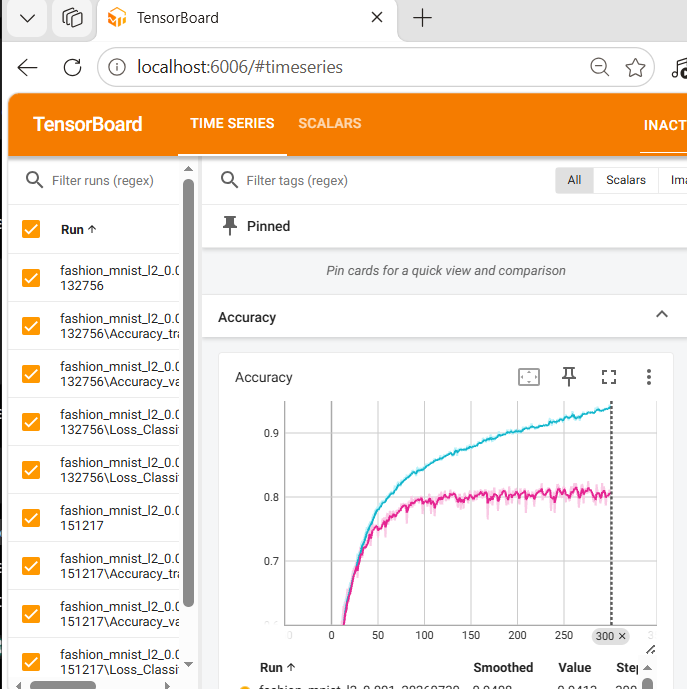